In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier


In [95]:
# read/load data
df = pd.read_csv("brca_metabric_clinical_data.tsv", sep='\t')

# replacing space with underscore
df.columns = df.columns.str.replace(" ", "_")
df = df.rename(columns={'Pam50_+_Claudin-low_subtype': 'Pam50_Claudin_low_subtype'})
print("Initial Data Shape:", df.shape)

Initial Data Shape: (2509, 39)


In [96]:
# number of missing values for each row
missing_per_row = df.isnull().sum(axis=1)

# data with rows that have 0 or exactly 1 missing value
df_clean = df[missing_per_row <= 1].copy()

print("Data Shape after keeping rows with <= 1 missing value:", df_clean.shape)

Data Shape after keeping rows with <= 1 missing value: (1690, 39)


In [97]:
# Isolating numerical columns for KNN (KNN only works on numbers)
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

imputer = KNNImputer(n_neighbors=5)
df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])

# Filling any remaining categorical missing values with 'Unknown'
cat_cols = df_clean.select_dtypes(include=['object']).columns
df_clean[cat_cols] = df_clean[cat_cols].fillna('Unknown')

df_clean.to_csv("clean_data.csv", index=False)
print("Data cleaning complete. Saved to 'clean_data.csv'")

Data cleaning complete. Saved to 'clean_data.csv'


/var/folders/nw/2dm_8qhd5rj3vc08k7bw9ss80000gn/T/ipykernel_82695/3999311494.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=['object']).columns


In [98]:
df1 = pd.read_csv("clean_data.csv")

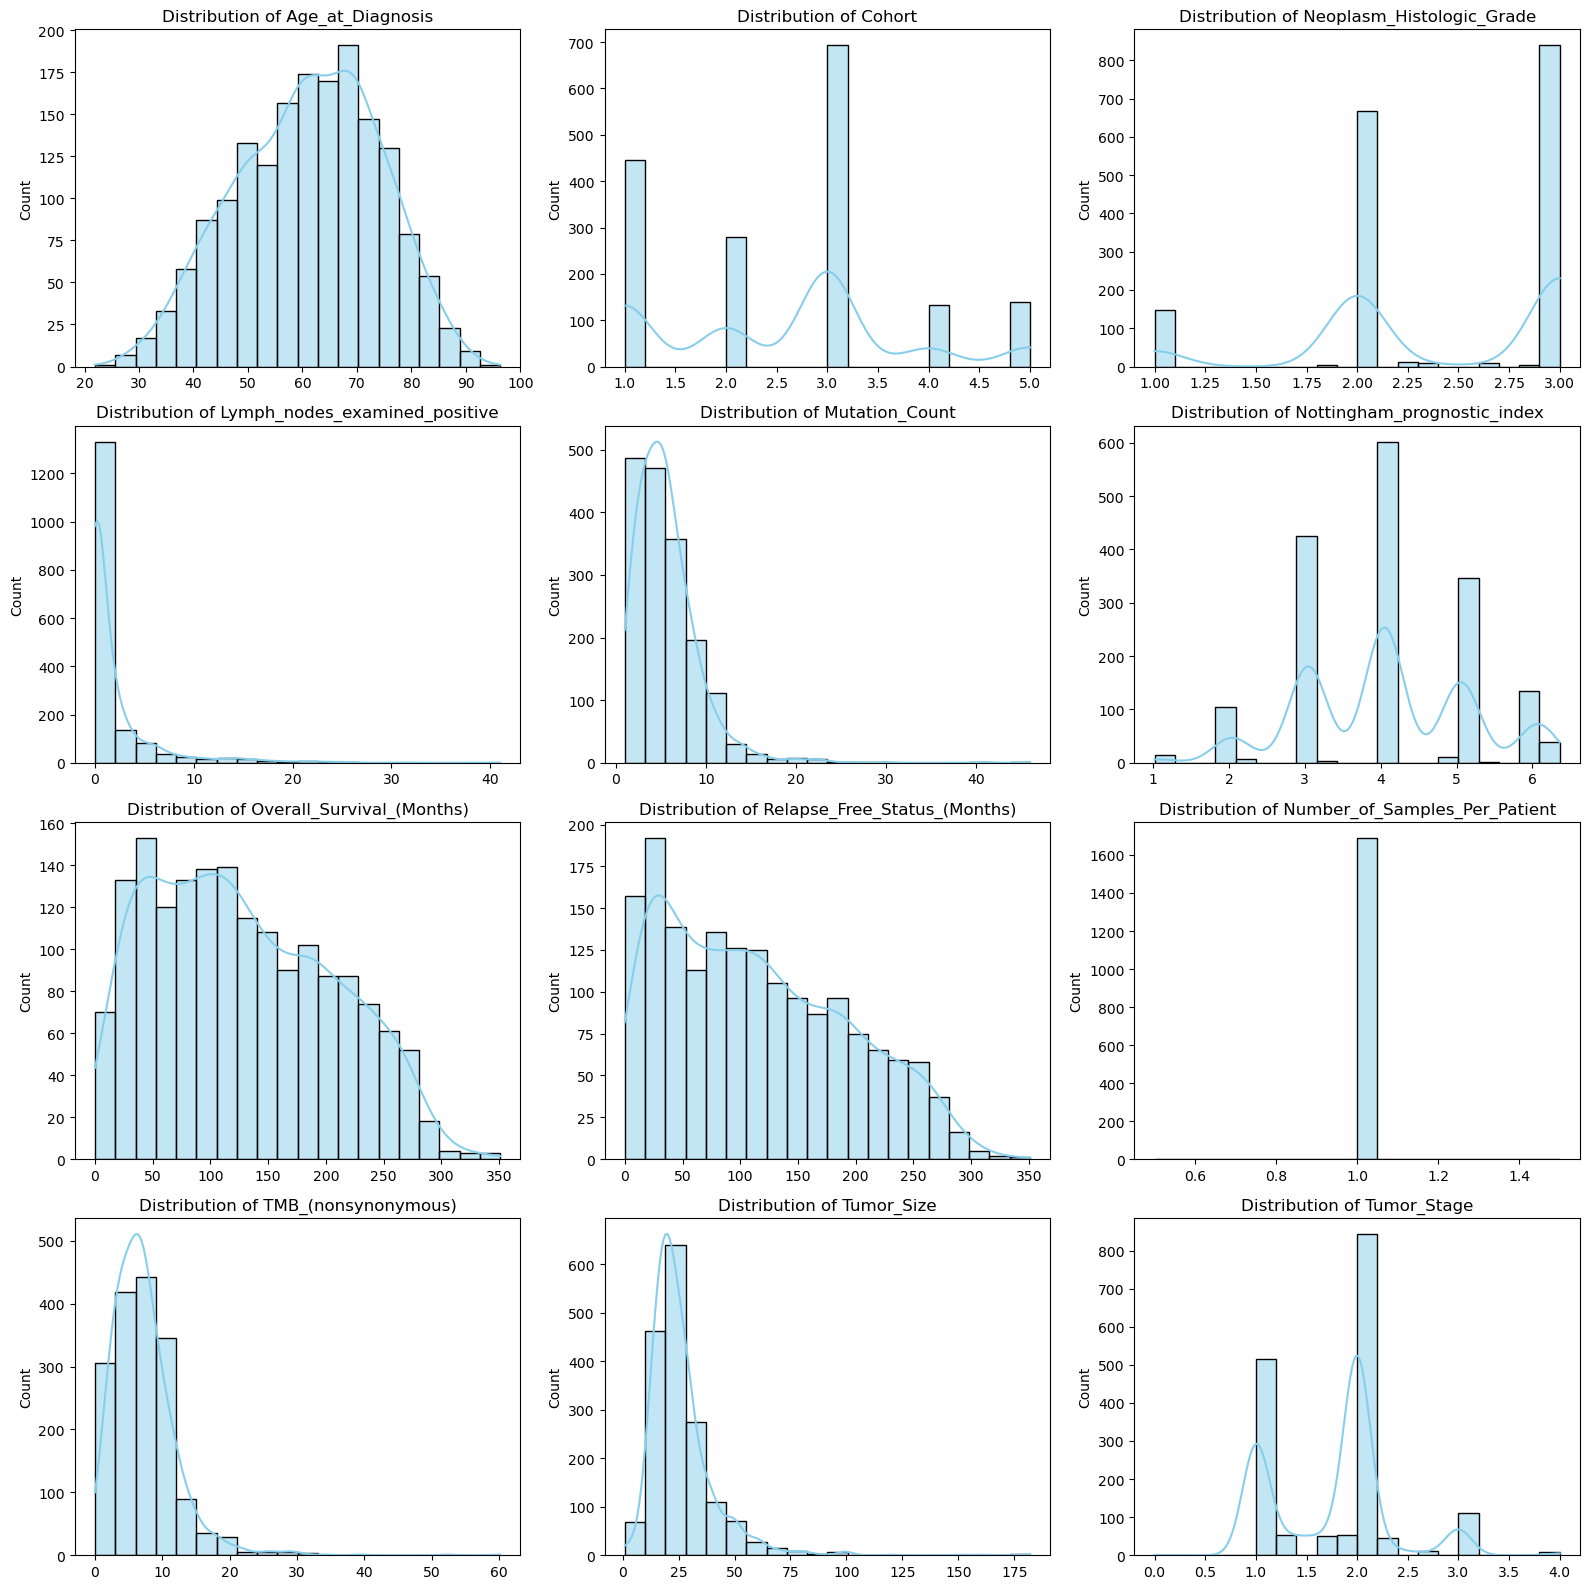

In [99]:
# Creating coloumns with float numbers (I do not want to use coloum with exactly one value here)
float_cols = df1.select_dtypes(include=['float64']).columns
num_plots = len(float_cols)

# Create the subplot grid layout
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 16))
# Flatten the axes array to easily loop through it with a single index
axes = axes.flatten()

# Loop through each float column and place it in the grid
for i, col in enumerate(float_cols):
    sns.histplot(df1[col].dropna(), bins=20, kde=True, color='skyblue', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('') 
    axes[i].set_ylabel('Count')

# Hide any empty subplot boxes in the last row
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

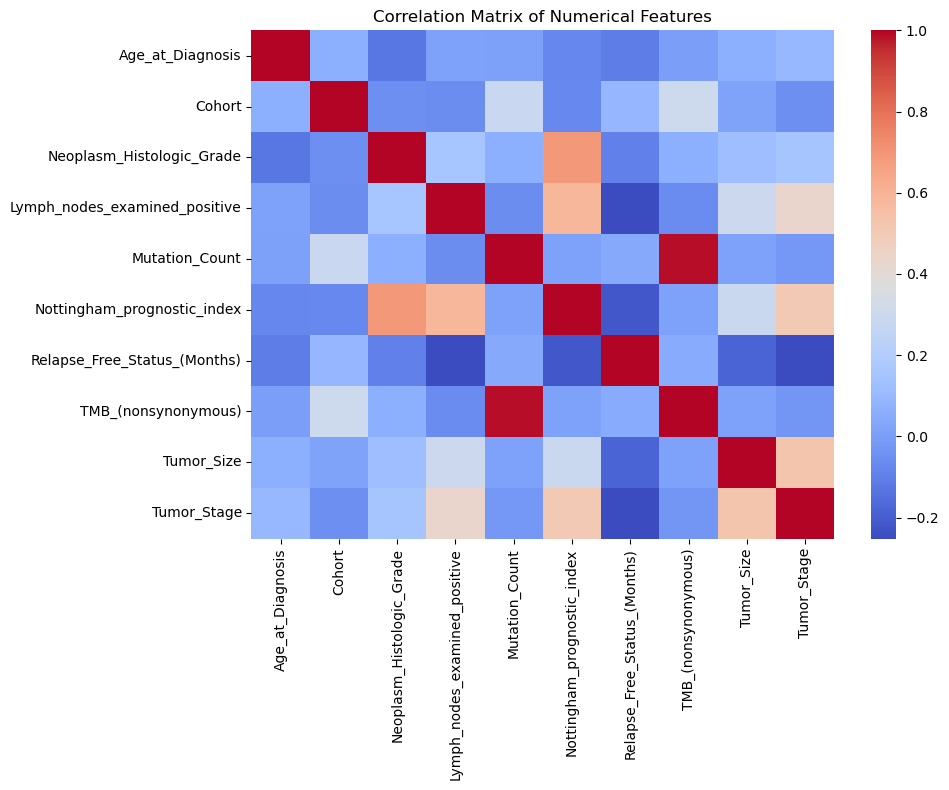

In [100]:
# Correlation Matrix of Numerical Features but excluding unneccesary columns
plt.figure(figsize=(10, 8))
numerical_df = df1.select_dtypes(include=['float64'])
cols_to_drop = ["Study_ID", "Patient_ID", "Sample_ID", "Cancer_Type", "Overall_Survival_(Months)", "Overall_Survival_Status", "Number_of_Samples_Per_Patient", "Sample_Type", "Sex", "Patient's_Vital_Status"]
numerical_df_filtered = numerical_df.drop(columns=[col for col in cols_to_drop if col in numerical_df.columns])
sns.heatmap(numerical_df_filtered.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [101]:

df = pd.read_csv("clean_data.csv")

# Removing not necessary columns and creating X and y 
cols_to_drop = ["Study_ID", "Patient_ID", "Sample_ID", "Cancer_Type", "Overall_Survival_(Months)", "Overall_Survival_Status", "Number_of_Samples_Per_Patient", "Sample_Type", "Sex", "Patient's_Vital_Status"]
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df["Patient's_Vital_Status"] 

# Encode the Target variable if 'Living' = 1, 'Died' = 0
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y.astype(str))

In [102]:
# Identify columns type of data
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

#print(f"One-hot encoding {len(categorical_cols)} categorical columns...")

# 2. Setup the ColumnTransformer
# 'encoder': applies OneHotEncoder to categorical columns and 'remainder='passthrough'
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

# Fit and transform features
X_encoded_array = preprocessor.fit_transform(X)

# Reconstruct into a clean pandas DataFrame with the new column names
encoded_feature_names = preprocessor.get_feature_names_out()

X_encoded = pd.DataFrame(X_encoded_array, columns=encoded_feature_names, index=X.index)

print("All features successfully converted using One-Hot Encoding!")
print(f"New DataFrame shape: {X_encoded.shape}") # have significantly more columns now!
X_encoded.head()

All features successfully converted using One-Hot Encoding!
New DataFrame shape: (1690, 86)


/var/folders/nw/2dm_8qhd5rj3vc08k7bw9ss80000gn/T/ipykernel_82695/2428400490.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


,cat__Type_of_Breast_Surgery_BREAST CONSERVING,cat__Type_of_Breast_Surgery_MASTECTOMY,cat__Type_of_Breast_Surgery_Unknown,cat__Cancer_Type_Detailed_Breast,cat__Cancer_Type_Detailed_Breast Invasive Ductal Carcinoma,cat__Cancer_Type_Detailed_Breast Invasive Lobular Carcinoma,cat__Cancer_Type_Detailed_Breast Invasive Mixed Mucinous Carcinoma,cat__Cancer_Type_Detailed_Breast Mixed Ductal and Lobular Carcinoma,cat__Cancer_Type_Detailed_Invasive Breast Carcinoma,cat__Cellularity_High,...,remainder__Age_at_Diagnosis,remainder__Cohort,remainder__Neoplasm_Histologic_Grade,remainder__Lymph_nodes_examined_positive,remainder__Mutation_Count,remainder__Nottingham_prognostic_index,remainder__Relapse_Free_Status_(Months),remainder__TMB_(nonsynonymous),remainder__Tumor_Size,remainder__Tumor_Stage
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,43.19,1.0,3.0,0.0,2.0,4.020,84.633333,2.615035,10.0,1.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,48.87,1.0,2.0,1.0,2.0,4.030,153.300000,2.615035,15.0,2.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,47.68,1.0,2.0,3.0,1.0,4.050,164.933333,1.307518,25.0,2.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,76.97,1.0,3.0,8.0,2.0,6.080,18.800000,2.615035,40.0,2.0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,78.77,1.0,3.0,0.0,4.0,4.062,2.933333,5.230071,31.0,4.0


In [103]:
# Initialization and fitting the RF Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_encoded, y_encoded)

# feature importances
individual_importances = rf.feature_importances_
block_importances = {}

# Categorical blocks: Match binary column names back to their original column prefix
for orig_col in categorical_cols:
    # ColumnTransformer names one-hot columns as 'cat__OriginalName_CategoryValue'
    prefix = f"cat__{orig_col}_"
    block_sum = sum(
        importance for name, importance in zip(encoded_feature_names, individual_importances)
        if name.startswith(prefix)
    )
    block_importances[orig_col] = block_sum

# Numerical blocks: These remain 1-to-1 as their own separate block
for orig_col in numerical_cols:
    # ColumnTransformer prepends 'remainder__' to passthrough numeric features
    prefix = f"remainder__{orig_col}"
    block_sum = sum(
        importance for name, importance in zip(encoded_feature_names, individual_importances)
        if name == prefix
    )
    block_importances[orig_col] = block_sum

In [104]:
# Convert the block dictionary to a sorted DataFrame for evaluation
feature_importance_df = pd.DataFrame({
    'Feature_Block': list(block_importances.keys()),
    'Importance': list(block_importances.values())
}).sort_values(by='Importance', ascending=False)

print("--- Top Feature Blocks ---")
print(feature_importance_df.head(10))

--- Top Feature Blocks ---
                   Feature_Block  Importance
17           Relapse_Free_Status    0.301824
19              Age_at_Diagnosis    0.093793
25  Relapse_Free_Status_(Months)    0.086916
12           Integrative_Cluster    0.045426
24   Nottingham_prognostic_index    0.044872
27                    Tumor_Size    0.036357
4      Pam50_Claudin_low_subtype    0.030249
20                        Cohort    0.028759
23                Mutation_Count    0.027763
26           TMB_(nonsynonymous)    0.026901


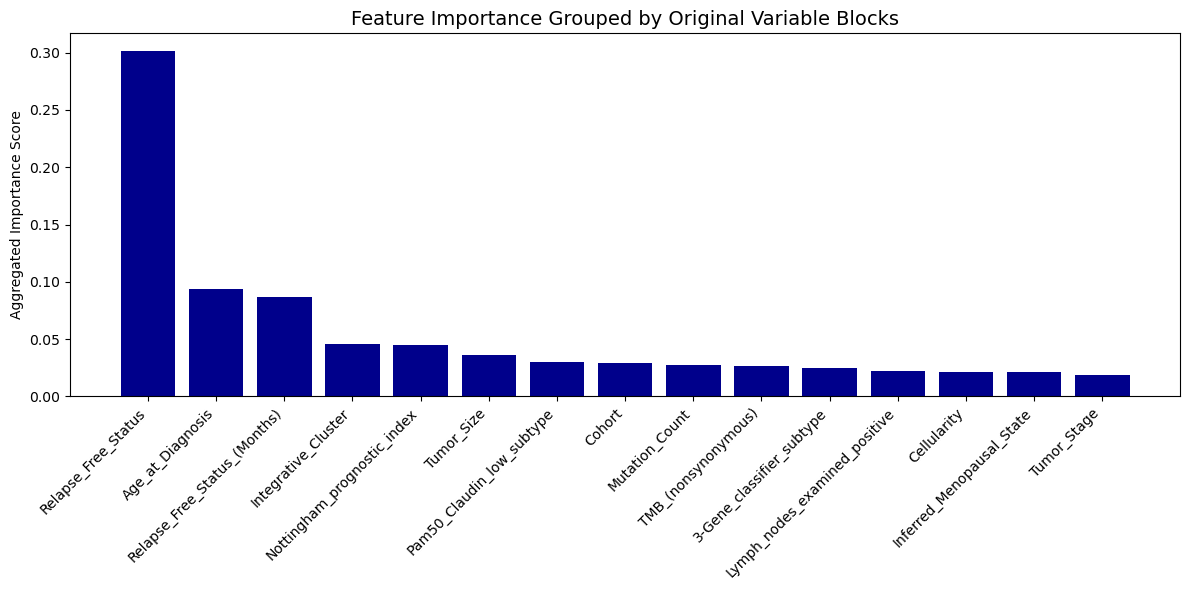

In [ ]:
# Plot aggregated Block Feature Importances
plt.figure(figsize=(12, 6))
plt.title("Feature Importance Grouped by Original Variable Blocks", fontsize=14)
plt.bar(feature_importance_df['Feature_Block'].head(15), 
        feature_importance_df['Importance'].head(15), 
        color="darkblue", align="center")
plt.xticks(rotation=45, ha='right')
plt.ylabel('Aggregated Importance Score')
plt.tight_layout()
plt.show()